# AUCp walkthrough

Pseudo-AUC (AUCp) lets you pick the best inference checkpoint **without any labeled validation data**. The recipe:

1. Score every training-normal sample and every unlabeled test sample with the candidate checkpoint.
2. Pretend every training sample is `label=0` and every test sample is `label=1`.
3. Compute AUC on those pseudo labels.

Higher AUCp → better separation → (usually) better real AUC. This notebook builds the intuition from scratch.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

from aucp import aucp_score, estimate_auc_from_aucp, select_best_checkpoint

rng = np.random.default_rng(0)

## 1. The setup

We have an anomaly detector. We can score samples but we don't have labels for the test set. We *do* know which samples are normal in our training set (that's why we trained on them).

Simulate a half-decent detector: it gives normals scores around 0 and abnormals scores around 1 (with overlap).

In [2]:
n_normal_train = 800
n_normal_test = 300
n_abnormal_test = 300

train_normal = rng.normal(loc=0.0, scale=1.0, size=n_normal_train)
test_normal = rng.normal(loc=0.0, scale=1.0, size=n_normal_test)
test_abnormal = rng.normal(loc=1.5, scale=1.0, size=n_abnormal_test)

test_scores = np.concatenate([test_normal, test_abnormal])
true_labels = np.concatenate([np.zeros(n_normal_test), np.ones(n_abnormal_test)])

print(f"True AUC (needs labels) : {roc_auc_score(true_labels, test_scores):.4f}")
print(f"AUCp     (no labels)    : {aucp_score(train_normal, test_scores):.4f}")

True AUC (needs labels) : 0.8853
AUCp     (no labels)    : 0.6738


AUCp lands below the true AUC. That offset is predictable: roughly half of the "unlabeled" set is actually normal, so the pseudo-positive distribution is contaminated. Eq. 12 in the paper undoes the bias if you know (or can estimate) the contamination $\rho$.

In [3]:
rho = n_normal_test / (n_normal_test + n_abnormal_test)
aucp = aucp_score(train_normal, test_scores)
print(f"contamination rho      : {rho:.3f}")
print(f"debiased AUC estimate  : {estimate_auc_from_aucp(aucp, rho):.4f}")
print(f"true AUC               : {roc_auc_score(true_labels, test_scores):.4f}")

contamination rho      : 0.500
debiased AUC estimate  : 0.8476
true AUC               : 0.8853


## 2. Why this works for *ranking* checkpoints

Even when AUCp is biased, what matters for checkpoint selection is whether it **ranks** checkpoints the same way the true AUC would. Let's simulate 30 epochs of training where the signal-to-noise ratio gradually improves, and watch the two curves move together.

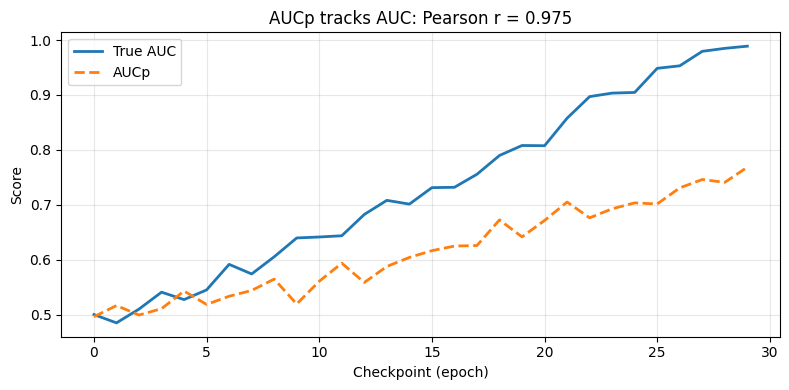

In [4]:
n_checkpoints = 30
aucs, aucps = [], []

for epoch in range(n_checkpoints):
    signal = epoch / (n_checkpoints - 1)
    noise = 1.0 - 0.7 * signal
    tr = rng.normal(0.0, noise, n_normal_train)
    tn = rng.normal(0.0, noise, n_normal_test)
    ta = rng.normal(signal, noise, n_abnormal_test)
    te = np.concatenate([tn, ta])
    y = np.concatenate([np.zeros(n_normal_test), np.ones(n_abnormal_test)])
    aucs.append(roc_auc_score(y, te))
    aucps.append(aucp_score(tr, te))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(aucs, label='True AUC', linewidth=2)
ax.plot(aucps, label='AUCp', linewidth=2, linestyle='--')
ax.set_xlabel('Checkpoint (epoch)')
ax.set_ylabel('Score')
ax.set_title(f'AUCp tracks AUC: Pearson r = {np.corrcoef(aucs, aucps)[0, 1]:.3f}')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
selected = select_best_checkpoint(list(enumerate(aucps)))
best_true = int(np.argmax(aucs))

print(f"AUCp picked epoch {selected.checkpoint} → true AUC = {aucs[selected.checkpoint]:.4f}")
print(f"Oracle would pick epoch {best_true} → true AUC = {aucs[best_true]:.4f}")

AUCp picked epoch 29 → true AUC = 0.9889
Oracle would pick epoch 29 → true AUC = 0.9889


## 3. When AUCp breaks down

AUCp's accuracy depends on (i) the training-normal set being large and representative, and (ii) the test set containing enough abnormals. Sweep the abnormal prevalence to see the failure mode in Fig. 5 of the paper.

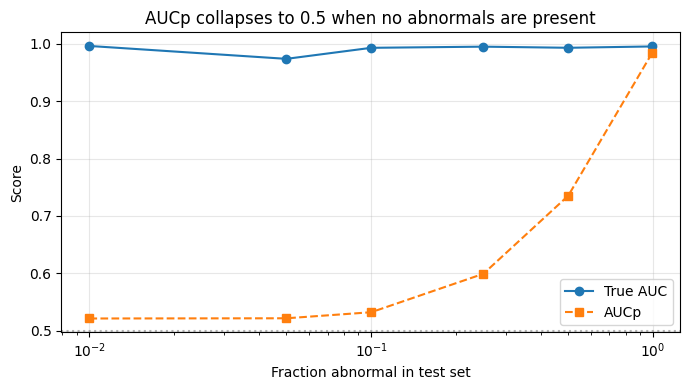

In [6]:
prevalences = [0.01, 0.05, 0.10, 0.25, 0.5, 0.99]
aucs_p, aucps_p = [], []
for p in prevalences:
    n_abn = max(int(600 * p), 1)
    n_norm = 600 - n_abn
    tr = rng.normal(0.0, 0.3, 2000)
    tn = rng.normal(0.0, 0.3, n_norm)
    ta = rng.normal(1.0, 0.3, n_abn)
    te = np.concatenate([tn, ta])
    y = np.concatenate([np.zeros(n_norm), np.ones(n_abn)])
    aucs_p.append(roc_auc_score(y, te))
    aucps_p.append(aucp_score(tr, te))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(prevalences, aucs_p, 'o-', label='True AUC')
ax.plot(prevalences, aucps_p, 's--', label='AUCp')
ax.set_xscale('log')
ax.set_xlabel('Fraction abnormal in test set')
ax.set_ylabel('Score')
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.6)
ax.set_title('AUCp collapses to 0.5 when no abnormals are present')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Plugging it into your training loop

```python
from aucp import aucp_score

best_aucp, best_state = -1.0, None
for epoch in range(num_epochs):
    train_one_epoch(model, train_loader)

    model.eval()
    train_scores = score_all(model, train_loader)   # known-normal
    test_scores  = score_all(model, test_loader)    # unlabeled
    score = aucp_score(train_scores, test_scores)
    if score > best_aucp:
        best_aucp = score
        best_state = copy.deepcopy(model.state_dict())

torch.save(best_state, 'best_by_aucp.pt')
```

That's the whole interface. The rest of this repo (`reconstruction/`, `ssl/`) shows it integrated with real abnormality-detection pipelines on seven medical-imaging datasets.